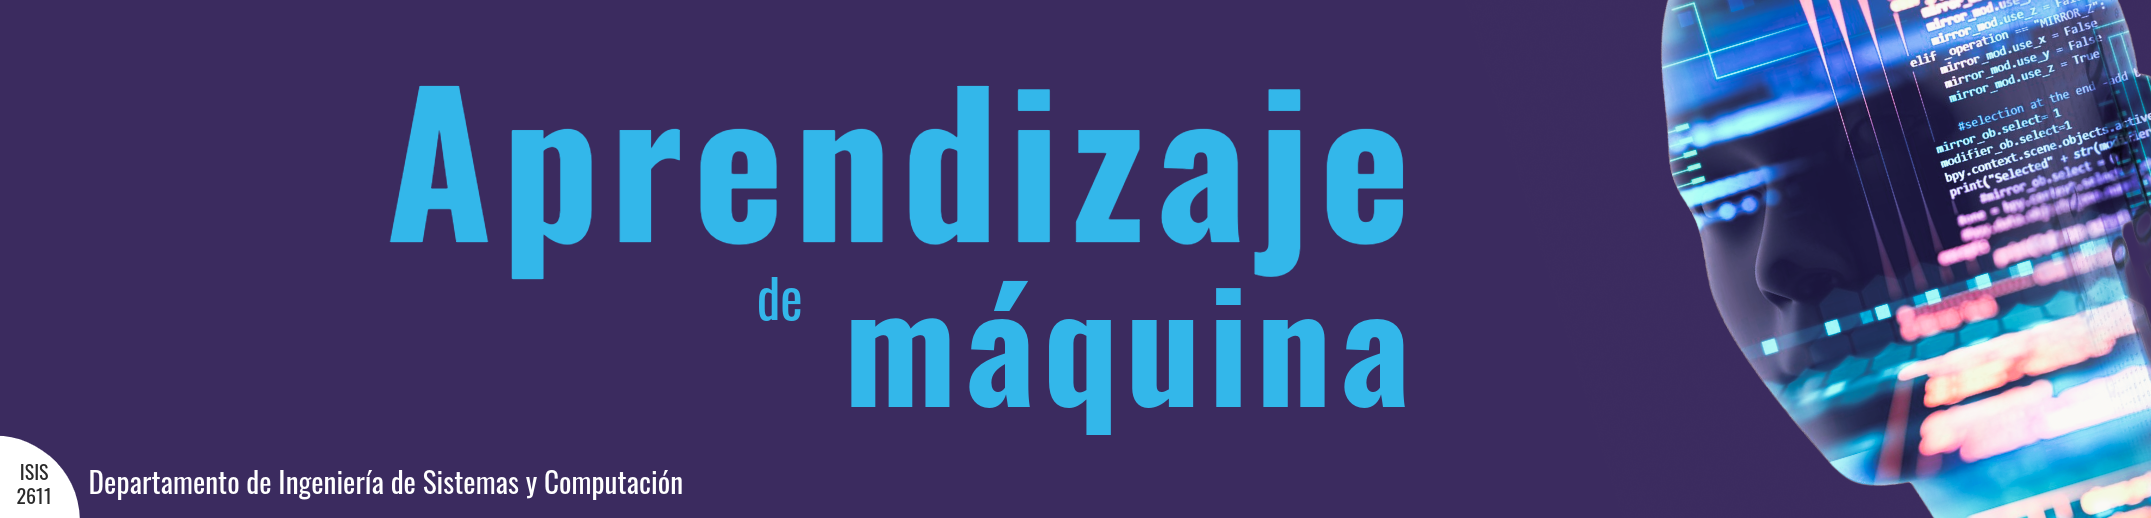


Estudiantes:

Camilo Molina – 202221119

Natalia Erazo – 202213680

# Laboratorio 1 - Exploración, preparación y regresión lineal

En este notebook se trabajará sobre el **Caso AlpesPlanck**:

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. Ellos han conocido el trabajo realizado por ustedes y están interesados en contratarlos para desarrollar un proyecto orientado a predecir la temperatura máxima de un día e identificar las variables metereológicas que más aportan a esa predicción, con el fin de diseñar estrategias que permitan mitigar problemas como incendios forestales o complicaciones relacionadas con fenómenos como "el Niño" o la "Niña".

Las actividades a realizar corresponden a: 
1. Exploración de los datos
2. Preparación de datos
3. Construcción de un modelo de regresión lineal
4. Evaluación cuantitativa
5. Evaluación cualitativa
6. Comunicar los resultados
7. Uso del modelo
8. Uso de herramienta de IA generativa


## 1. Exploración de los datos

Como primer paso se importan las librerías con las que se va a trabajar. Además, se revisan las versiones de las librerías a usar para propósitos de documentación. El laboratorio se resuelve utilizando las siguientes versiones:

Versión de Pandas: 2.2.3

Versión de Matplotlib: 3.9.2

Versión de Seaborn: 0.13.2


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

Versión de Pandas: 2.2.3
Versión de Matplotlib: 3.9.2
Versión de Seaborn: 0.13.2


### 1.1 Cargar del conjunto de datos

Se carga el archivo haciendo uso de la función read_csv().

In [3]:
datos_meteorologicos = pd.read_csv('./data/DatosLab1.csv', )

#copia de los datos
data = datos_meteorologicos.copy()

Para tener una primera visión de los datos usaremos la función head():

In [4]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


> **Observación**: la validez en los datos de 'mes' no se cumple, según las 5 primeras filas: enero se representa como JANUARY y January.

### 1.2 Estructura del dataset

Para conocer el tamaño del conjunto de datos usamos la función `shape`:

In [5]:
data.shape

(2576, 27)

Esto nos dice que el conjunto de datos está compuesto por 2576 registros y 27 variables.

Para un primer acercamiento al tipo de dato de cada columna y al conteo de datos nulos usamos `data.info()`.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

> **Observación**: inicialmente se detectan valores nulos en múltiples columnas.

Identificamos las columnas específicas con valores nulos:

In [7]:
cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

print('Columnas con valores nulos:', cols_con_null)
print('Cantidad de columnas con nulos:', len(cols_con_null))

nulls = []

for col in cols_con_null:
    nulos = data[col].isna().sum()
    porcentaje = nulos / len(data) * 100
    
    nulls.append([col, nulos, porcentaje])

tabla_nulls = pd.DataFrame(
    nulls,
    columns=['Columna', 'Valores nulos', 'Porcentaje (%)']
)

tabla_nulls['Porcentaje (%)'] = tabla_nulls['Porcentaje (%)'].round(2)

display(tabla_nulls)

Columnas con valores nulos: ['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']
Cantidad de columnas con nulos: 27


,Columna,Valores nulos,Porcentaje (%)
0,fecha,72,2.80
1,presion_media,75,2.91
2,presion_min,74,2.87
3,presion_max,64,2.48
4,presion_desv,80,3.11
5,humedad_media,74,2.87
6,humedad_min,80,3.11
7,humedad_max,86,3.34
8,humedad_desv,61,2.37
9,viento_media,86,3.34


Se evidencia que en todas las 27 columnas hay datos nulos.

Ahora se explora el diccionario de datos:

In [8]:
dict = pd.read_excel('./data/DiccionarioDeDatos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Con el diccionario podemos entender el significado y rango válido de cada variable.

Se intuye:

- 'anio', 'mes' y 'dia_del_anio' deben coincidir con los datos de la columna 'fecha'.

- los datos de [varible]_media den ser mayores a [varible]_min y menores a [varible]_max.

- la estacion_anio debe coincidir con la fecha (hemisferio norte por Jena, Alemania).


Ahora clasificamos las columnas según su tipo estadístico:

In [9]:
# Clasificamos las columnas según su tipo estadístico
# basándonos en el diccionario de datos y el contexto del problema

cuantitativas_continuas = ['presion_media', 'presion_min', 'presion_max', 'presion_desv',
                           'humedad_media', 'humedad_min', 'humedad_max','humedad_desv',
                           'viento_media', 'viento_min', 'viento_max','viento_desv',
                           'rafaga_media', 'rafaga_min', 'rafaga_max','rafaga_desv',
                           'viento_norte', 'viento_este',
                           'direccion_viento']
cuantitativas_discretas = ['registros_del_dia', 'anio', 'dia_del_anio']
cualitativas_ordinales  = []
cualitativas_nominales  = ['estacion_anio', 'sector_viento', 'mes']



print("Cuantitativas continuas :", cuantitativas_continuas)
print("Cuantitativas discretas :", cuantitativas_discretas)
print("Cualitativas ordinales  :", cualitativas_ordinales)
print("Cualitativas nominales  :", cualitativas_nominales)

Cuantitativas continuas : ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento']
Cuantitativas discretas : ['registros_del_dia', 'anio', 'dia_del_anio']
Cualitativas ordinales  : []
Cualitativas nominales  : ['estacion_anio', 'sector_viento', 'mes']


### 1.3 Descripción de los datos
Para obtener mediciones estadísticas (como la media, la desviación estándar, el mínimo, el máximo y una separación por cuartiles) y una descripción más clara de los datos usamos la función `describe()`.


In [10]:
pd.set_option('display.max_columns', None)

data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,2495.000000,2504.000000,2498.000000,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,7.647484,13.859643,2.988370,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,6.785897,76.009623,27.846414,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,3.370000,0.757000,2.511875,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,5.051746,1.054850,3.228800,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,9.630000,1.571550,4.264600,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


#### Descripción de variables cualitativas

Usamos `describe()` con el parámetro `include='object'` para estudiar las variables de tipo `object` (categóricas / texto).

Esto nos devuelve:

- `count`: valores no nulos.
- `unique`: cuántos valores distintos existen.
- `top`: valor más frecuente (moda).
- `freq`: cuántas veces aparece ese valor.

> **Observaciones**:
> - Encontramos problemas de consistencia para estacion_anio pues hay 28 valores posibles y solo deberían ser 4.
> - Encontramos problemas de consistencia para mes pues hay 61 valores posibles y solo deberían ser 12.
> - Encontramos problemas de consistencia para sector_viento pues hay 33 valores posibles y solo deberían ser 8.


In [11]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2010-08-14,primavera,May,SO
freq,2,517,127,695


In [12]:
# Revisar formatos para ver cuántas representaciones diferentes de los mismos datos hay y cuáles son...

objetos = ['estacion_anio', 'mes', 'sector_viento'
] 

for i in objetos:
    print("Valores únicos en " + i + ":")
    print(data[i].unique())
    print(f"Total de valores únicos: {data[i].nunique()} \n\n")

Valores únicos en estacion_anio:
['invierno' 'East' nan 'Estacion_Desconocida' 'verano' 'Inverano'
 'invierno ' 'INVIERNO' 'VERANO_INVIERNO' 'Verano' 'primavera' 'Primavera'
 'primaveraa' 'PRIMAVERA' 'berano' 'VERANO' 'verno' 'otono' 'otoño '
 'fall' 'autumn' 'OTONO' 'winter' 'invernio' 'primav' 'spring' 'Otoño'
 'Invierno' 'summer']
Total de valores únicos: 28 


Valores únicos en mes:
['January' 'JULY' 'JANUARY' 'May' 'Enero' nan 'JUNE' 'Sep' 'April'
 'SEPTEMBER' 'noviembre' 'octubre' 'Sept' 'november' 'april' 'julio'
 'February' 'APRIL' 'Aug' 'febrero' 'septiembre' 'Mar' 'Nov' 'MARCH'
 'february' 'November' 'may' 'july' 'august' 'september' 'July' 'March'
 'October' 'junio' 'october' 'march' 'marzo' 'September' 'Oct' 'DECEMBER'
 'Jan' 'enero' 'NOVEMBER' 'december' 'Jul' 'OCTOBER' 'Jun' 'diciembre'
 'AUGUST' 'June' 'january' 'june' 'Feb' 'August' 'December' 'agosto' 'Apr'
 'mayo' 'abril' 'FEBRUARY' 'MAY' 'Dec']
Total de valores únicos: 61 


Valores únicos en sector_viento:
['S' 'NE'

Para conocer el número de veces que cada valor aparece en una las columnas, usamos la función `value_counts()`:


In [13]:
for i in objetos:
    display(data[i].value_counts())

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Invierno                  9
Verano                    9
invierno                  9
INVIERNO                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

mes
May           127
August        125
July          123
January       120
March         118
             ... 
septiembre     16
april          16
junio          16
OCTOBER        13
Jan            13
Name: count, Length: 61, dtype: int64

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
ne            19
South         19
NORTHEAST     17
Sur           16
Noreste       12
SOUTH          8
o              8
no             6
NORTH          6
West           5
WEST           5
EAST           4
North          4
East           4
SOUTHEAST      3
Sureste        3
Oeste          3
Noroeste       3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

### 1.4 Datos duplicados

Revisamos cuántas filas de datos se encuentran totalmente duplicadas:

In [14]:
display(data.duplicated().sum())

display(data[data.duplicated(keep=False)])

np.int64(4)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600


> **Observación**: Se detectan **4 filas completamente duplicadas** que serán eliminadas en la fase de preparación.

### 1.5 Visualización de variables

#### Boxplot de variables numéricas



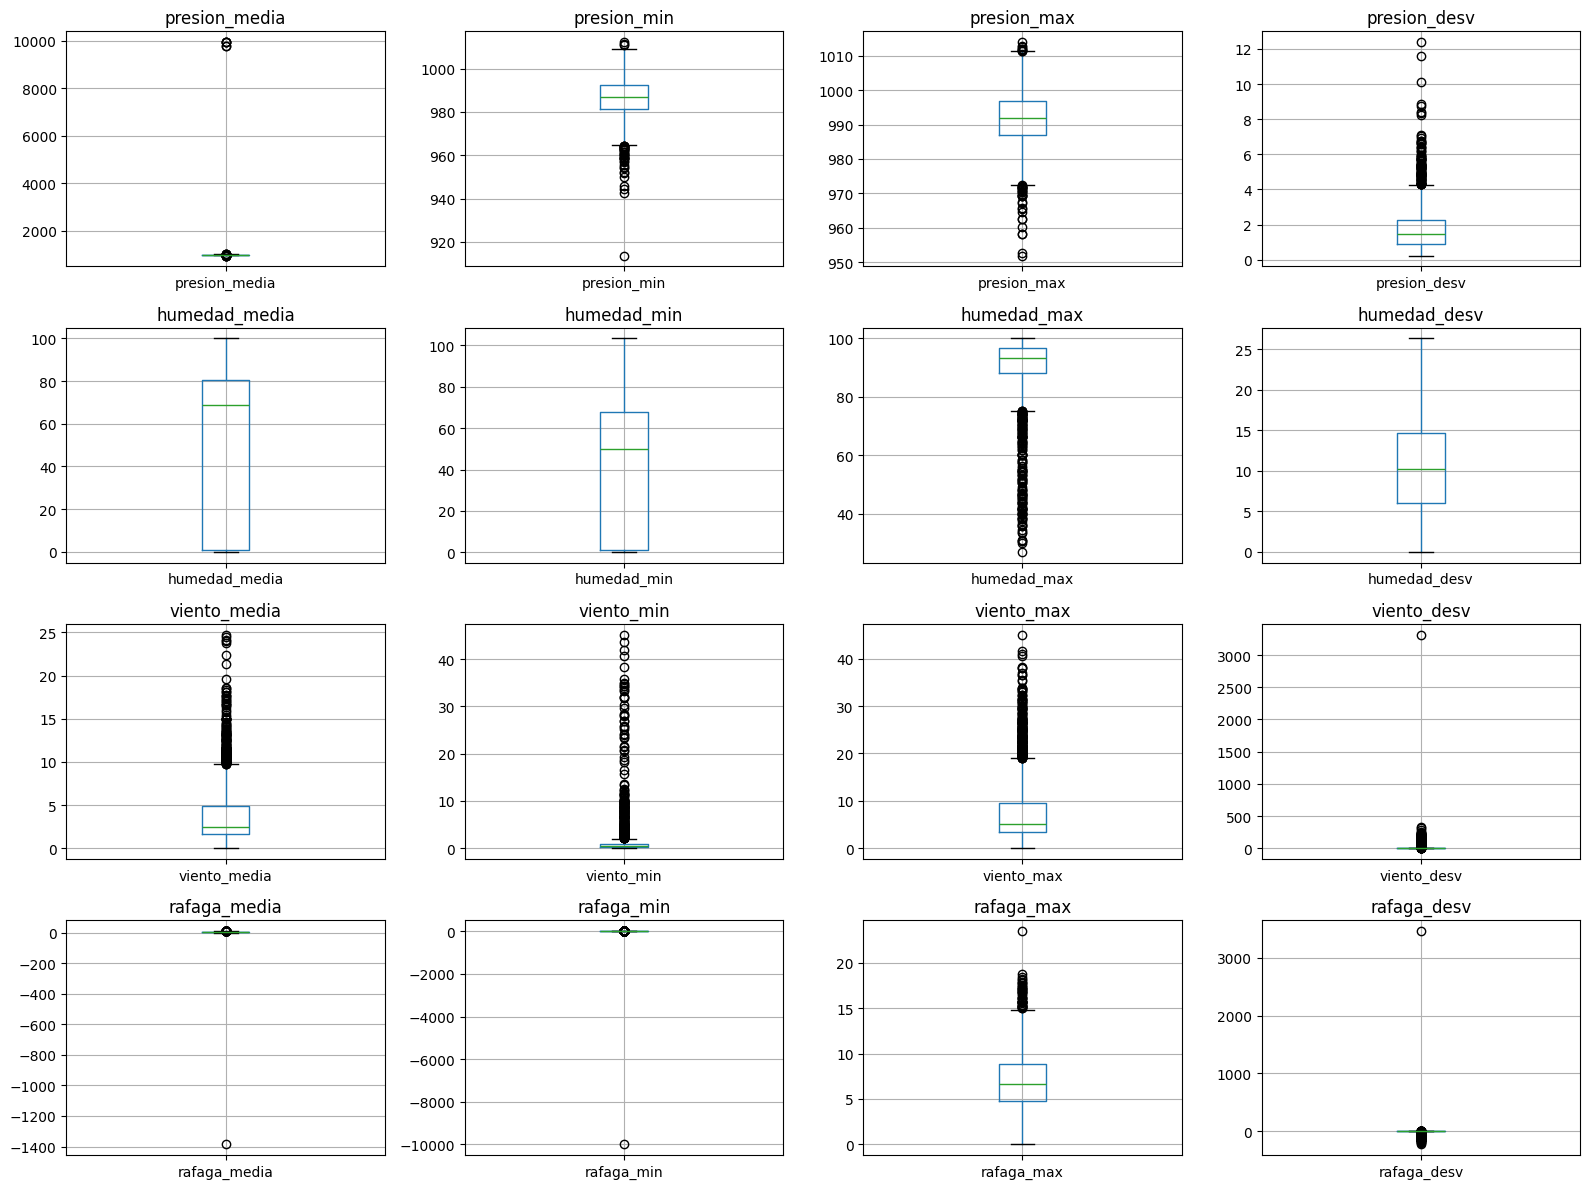

In [15]:
# Se incluyen unicamente variables numericas para los boxplots
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        data.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

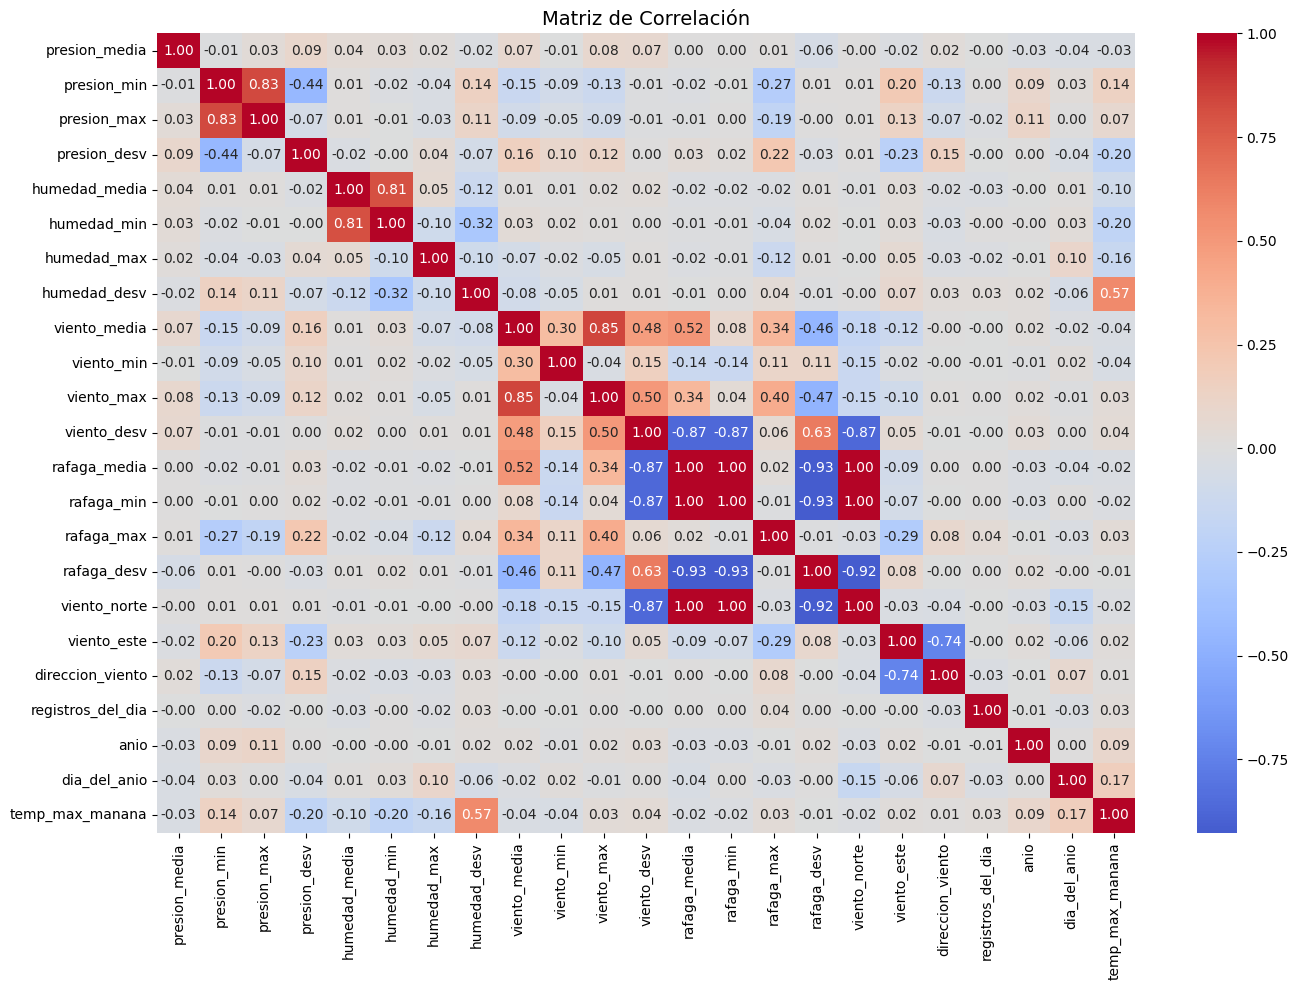

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

#### Comparación de media, mínimo y máximo por Variable

Creamos gráficas comparativas para las variables principales, mostrando cómo varían la media, el mínimo y el máximo.

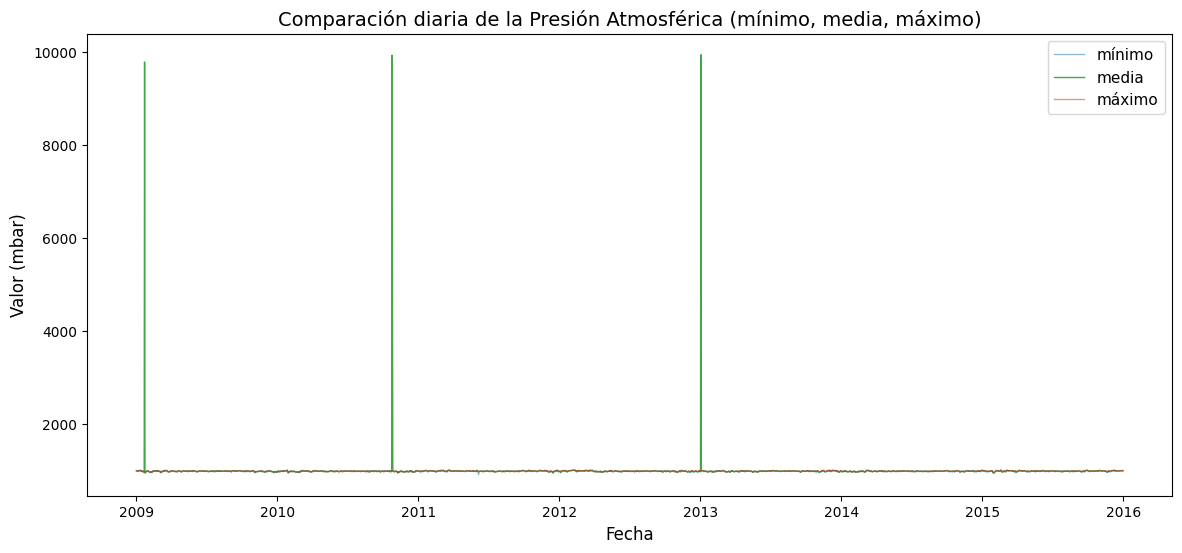

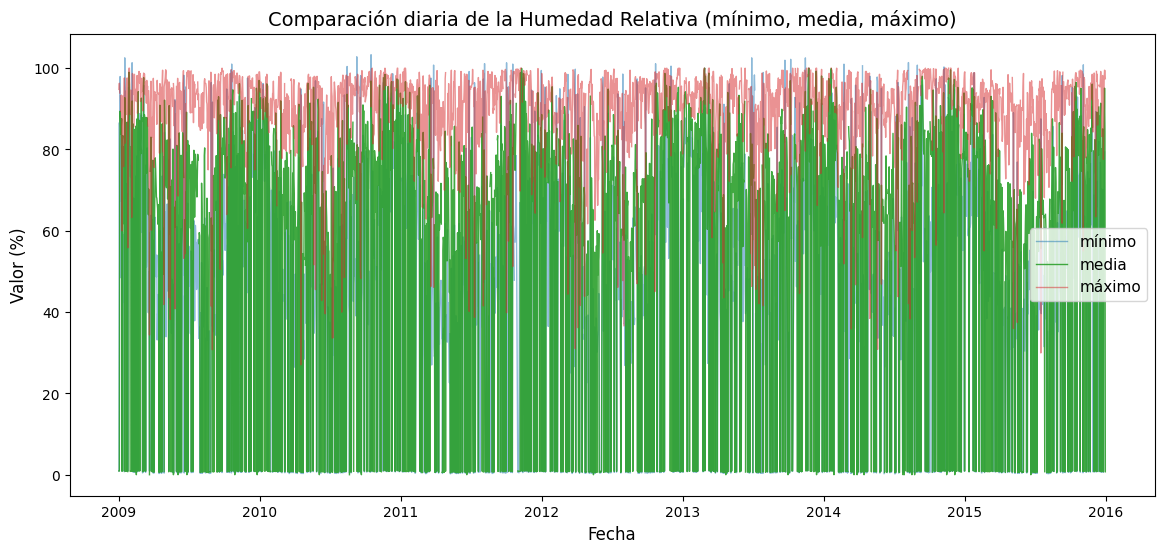

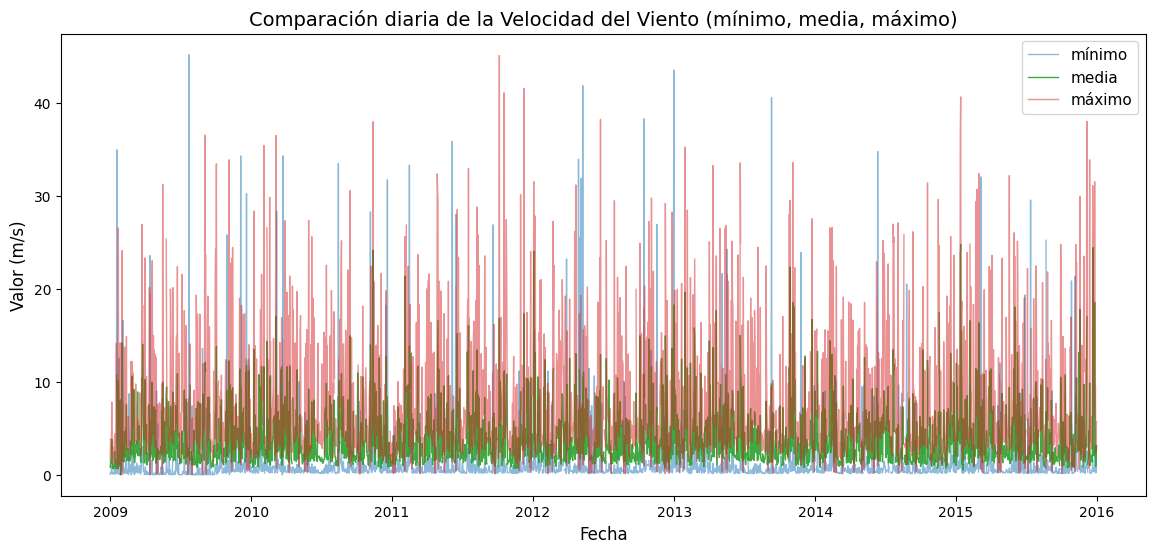

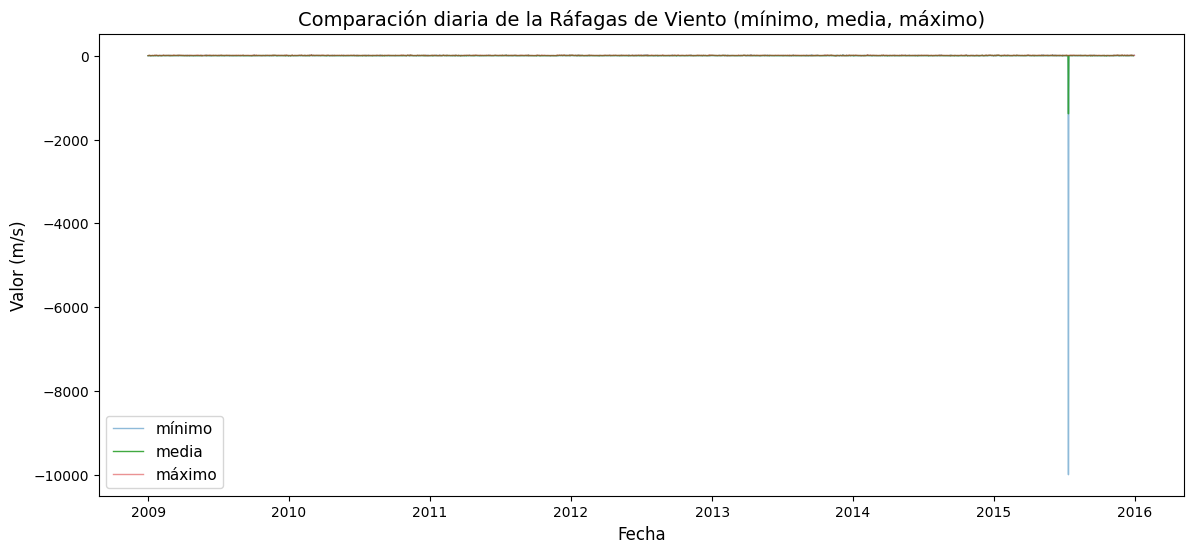

In [17]:
data['fecha'] = pd.to_datetime(data['fecha'])
data = data.sort_values('fecha')

variables = {
    'presion': ('Presión Atmosférica', 'mbar'),
    'humedad': ('Humedad Relativa', '%'),
    'viento': ('Velocidad del Viento', 'm/s'),
    'rafaga': ('Ráfagas de Viento', 'm/s')
}

colores = {
    'min': '#1f77b4',
    'media': '#2ca02c',
    'max': '#d62728'
}

for variable, (titulo, unidad) in variables.items():
    plt.figure(figsize=(14, 6))

    minimo = data[variable + '_min']
    media = data[variable + '_media']
    maximo = data[variable + '_max']

    plt.plot(data['fecha'], minimo,
             label='mínimo', color=colores['min'], alpha=0.5, linewidth=1)

    plt.plot(data['fecha'], media,
             label='media', color=colores['media'], alpha=0.9, linewidth=1)

    plt.plot(data['fecha'], maximo,
             label='máximo', color=colores['max'], alpha=0.5, linewidth=1)

    plt.title(
        f'Comparación diaria de la {titulo} (mínimo, media, máximo)',
        fontsize=14
    )
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(f'Valor ({unidad})', fontsize=12)
    plt.legend(fontsize=11)
    plt.show()

#### Frecuencias de variables

Observamos la frecuencia de las direcciones del viento.

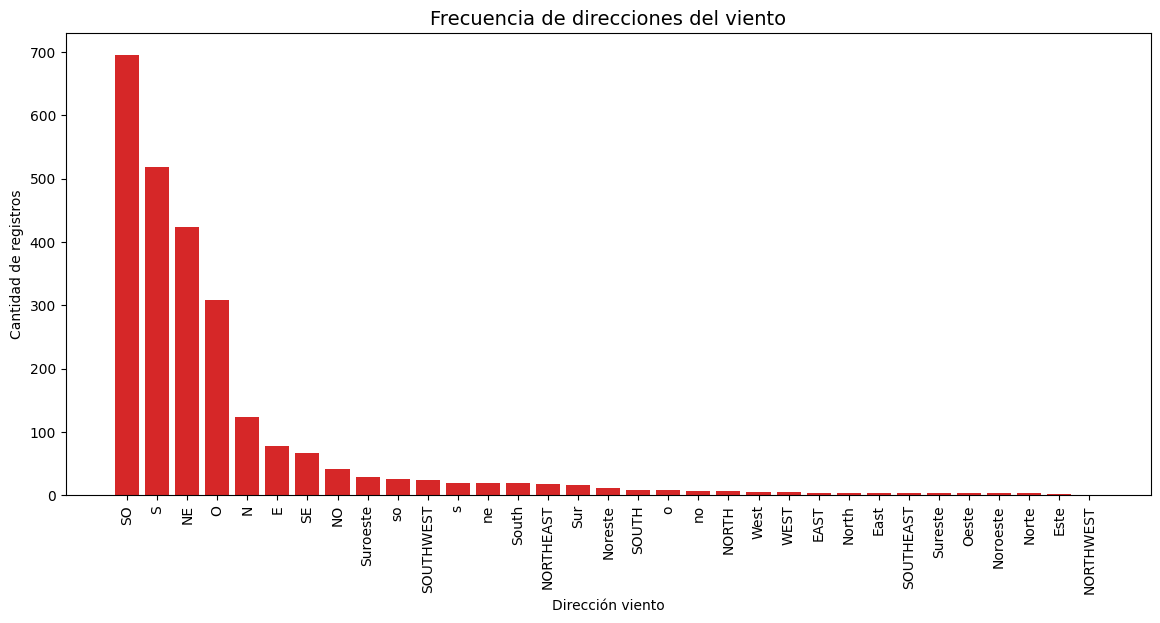

In [18]:
plt.figure(figsize=(14, 6))

viento_counts = data['sector_viento'].value_counts()

plt.bar(
    viento_counts.index,
    viento_counts.values,
    color='#d62728'
)

plt.title('Frecuencia de direcciones del viento', fontsize=14)
plt.xlabel('Dirección viento')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=90)
plt.show()

#### Variación de temperatura por estación

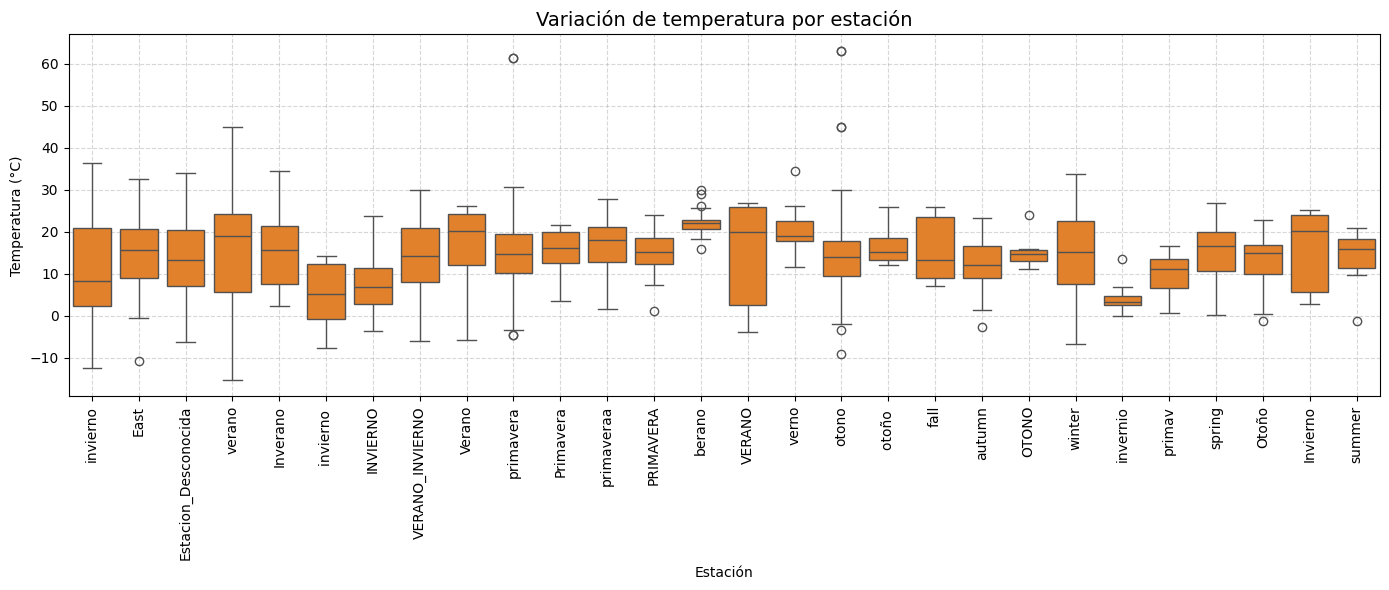

In [19]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    x=data['estacion_anio'],
    y=data['temp_max_manana'],
    color='#ff7f0e'
)

plt.title('Variación de temperatura por estación', fontsize=14)
plt.xlabel('Estación')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Distribución de la temperatura máxima mañana

Observamos cómo se comporta la variable objetivo que es la temperatura máxima del día siguiente.

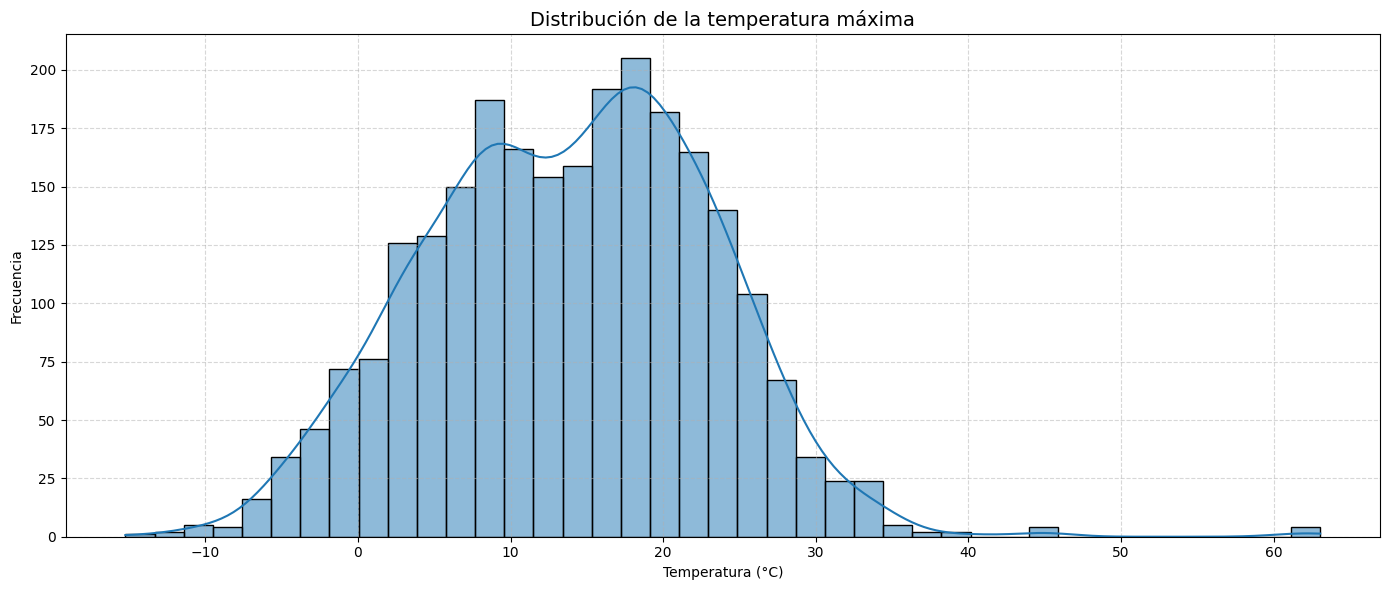

In [20]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data['temp_max_manana'],
    kde=True,
    color='#1f77b4'
)

plt.title('Distribución de la temperatura máxima', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 1.6 Hallazgos de la exploración

#### Observaciones:

- sector_viento y estacion_anio no cumplen con las categorias, no son consistentes
- La cantidad de valores nulos por categoria es relativamente bajo: menor a 3,7% en todos los casos

#### Valores imposibles detectados:

- Valor de humedad mínima mayor a 100%
- El max de registros_del_dia supera el máximo permitido de 144, pues es 287
- Ráfaga de viento de -10000 m/s
- Valores mínimos mayores a la media y al máximo
- Temperatura máxima de 63° C. La temperatura más alta registrada en Jena corrsponde a aproximadamente 40° C.
- rafaga_media con valores negativos.

#### Outliers extremos pero posibles:

- Valores muy bajos de humedad, podrían ser días extremadamente secos
- Aunque la temperatura mínima de Jena en invierno es de aproximadamente -5°C, sería posible, en casos extremos, que la temperatura baje a -15°C.


#### Decisiones para la preparación:

- Eliminar duplicados
- Ajustar columnas categóricas
- Tratar valores imposibles como NaN
- verificar si las fechas coinciden

#### Multicolinealidad detectada:
- 

#### Correlaciones con temperatura máxima:

#### Correlaciones con temperatura máxima (categóricas):



## 2. Preparación de datos

### 2.1 Eliminar duplicados
Se eliminan las filas duplicadas detectadas en la exploración.

In [21]:
data = data.drop_duplicates()

In [22]:
data1 = data.copy()
data1["fecha"] = pd.to_datetime(data1["fecha"], format='mixed')
data1

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.778600,0.050000,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.419500,0.220000,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.250900,0.120000,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.720400,0.540000,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.800300,1.000000,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,NaT,991.9774,989.70,994.19,1.4006,0.608340,0.390500,80.8,14.2611,1.847600,0.240000,NaN,0.9015,3.1481,NaN,6.440000,1.2568,0.6842,0.5186,37.1636,144.0,2015.0,217.0,Inverano,August,NE,34.41
2434,NaT,983.5712,980.65,989.33,2.4154,70.488800,44.410000,84.7,13.7964,1.543600,10.294322,0.236121,1.0316,3.0192,0.88,7.238972,2.0331,-0.7062,-0.7043,224.9255,144.0,2015.0,244.0,otono,september,SO,20.03
2464,NaT,1004.4446,1002.62,1006.43,1.2320,0.006877,0.447600,94.2,17.3187,1.892400,0.160000,2.305028,1.7750,3.0048,0.36,5.623408,2.6245,1.0049,1.3243,52.8086,144.0,2015.0,274.0,Otoño,October,NE,17.35
2529,NaT,1002.1970,999.08,1005.34,2.0512,78.005500,57.340000,93.7,10.8056,10.956240,2.628000,26.388000,1.6727,4.7458,1.56,10.570000,2.2509,-2.8320,-0.6315,192.5714,144.0,2015.0,339.0,summer,JANUARY,S,9.80


### 2.2 Manejo de columnas categóricas

In [23]:
data1['estacion_anio'] = data1['estacion_anio'].replace(
    ['inverno', 'INVIERNO', 'invernio', 'Invierno', 'invierno ', 'winter'],
    'invierno'
)

data1['estacion_anio'] = data1['estacion_anio'].replace(
    ['Verano', 'berano', 'VERANO', 'verno', 'summer'],
    'verano'
)

data1['estacion_anio'] = data1['estacion_anio'].replace(
    ['Primavera', 'primaveraa', 'PRIMAVERA', 'primav', 'spring'],
    'primavera'
)

data1['estacion_anio'] = data1['estacion_anio'].replace(
    ['otoño ', 'autumn', 'fall', 'OTONO', 'Otoño'],
    'otono'
)

data1['mes'] = data1['mes'].replace(
    ['january', 'January', 'JANUARY', 'enero', 'Jan'],
    'enero'
)

data1['mes'] = data1['mes'].replace(
    ['february', 'February', 'FEBRUARY', 'febrero', 'Feb'],
    'febrero'
)

data1['mes'] = data1['mes'].replace(
    ['march', 'March', 'MARCH', 'marzo', 'Mar'],
    'marzo'
)

data1['mes'] = data1['mes'].replace(
    ['april', 'April', 'APRIL', 'abril', 'Apr'],
    'abril'
)

data1['mes'] = data1['mes'].replace(
    ['may', 'May', 'MAY', 'mayo'],
    'mayo'
)

data1['mes'] = data1['mes'].replace(
    ['june', 'June', 'JUNE', 'junio', 'Jun'],
    'junio'
)

data1['mes'] = data1['mes'].replace(
    ['july', 'July', 'JULY', 'julio', 'Jul'],
    'julio'
)

data1['mes'] = data1['mes'].replace(
    ['august', 'August', 'AUGUST', 'agosto', 'Aug'],
    'agosto'
)

data1['mes'] = data1['mes'].replace(
    ['september', 'September', 'SEPTEMBER', 'septiembre', 'Sep', 'Sept'],
    'septiembre'
)

data1['mes'] = data1['mes'].replace(
    ['october', 'October', 'OCTOBER', 'octubre', 'Oct'],
    'octubre'
)

data1['mes'] = data1['mes'].replace(
    ['november', 'November', 'NOVEMBER', 'noviembre', 'Nov'],
    'noviembre'
)

data1['mes'] = data1['mes'].replace(
    ['december', 'December', 'DECEMBER', 'diciembre', 'Dec'],
    'diciembre'
)

#manejo de estaciones raras
mapeo_estacion_desde_mes = {
    'diciembre': 'invierno', 'enero': 'invierno', 'febrero': 'invierno',
    'marzo': 'primavera', 'abril': 'primavera', 'mayo': 'primavera',
    'junio': 'verano', 'julio': 'verano', 'agosto': 'verano',
    'septiembre': 'otono', 'octubre': 'otono', 'noviembre': 'otono'
}

data1['estacion_anio'] = data1['mes'].map(mapeo_estacion_desde_mes)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['N', 'North', 'NORTH', 'Norte'],
    'N'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['NE', 'Noreste', 'NORTHEAST', 'ne'],
    'NE'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['E', 'East', 'EAST', 'Este'],
    'E'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['SE', 'Sureste', 'SOUTHEAST'],
    'SE'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['S', 'South', 'Sur', 's', 'SOUTH'],
    'S'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['SO', 'Suroeste', 'so', 'SOUTHWEST'],
    'SO'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['O', 'Oeste', 'o', 'West', 'WEST'],
    'O'
)

data1['sector_viento'] = data1['sector_viento'].replace(
    ['NO', 'Noroeste', 'NORTHWEST', 'no'],
    'NO'
)

#comprobación
objetos = ['estacion_anio', 'mes', 'sector_viento'] 

for i in objetos:
    print("Valores únicos en " + i + ":")
    print(data1[i].unique())
    print(f"Total de valores únicos: {data1[i].nunique()} \n\n")

Valores únicos en estacion_anio:
['invierno' 'verano' 'primavera' nan 'otono']
Total de valores únicos: 4 


Valores únicos en mes:
['enero' 'julio' 'mayo' 'Enero' nan 'junio' 'septiembre' 'abril'
 'noviembre' 'octubre' 'febrero' 'agosto' 'marzo' 'diciembre']
Total de valores únicos: 13 


Valores únicos en sector_viento:
['S' 'NE' 'SO' 'N' 'SE' nan 'O' 'E' 'NO']
Total de valores únicos: 8 




### 2.3 Válidez

In [25]:
import pandas as pd

# 1. Creamos el mapeo de número de mes a nombre en español
meses_nombre = {
    1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril',
    5: 'mayo', 6: 'junio', 7: 'julio', 8: 'agosto',
    9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
}

# 2. Comparamos los valores calculados de la fecha vs tus columnas
error_anio = data1['anio'].astype('Int64') != data1['fecha'].dt.year
error_dia  = data1['dia_del_anio'].astype('Int64') != data1['fecha'].dt.dayofyear
error_mes  = data1['mes'].str.lower() != data1['fecha'].dt.month.map(meses_nombre)

# 3. Mascara general para filas con al menos un error
filas_con_error = error_anio | error_dia | error_mes

# 4. Imprimir resumen
print(f"Total de filas con inconsistencias: {filas_con_error.sum()}")
print(f"- Inconsistencias en 'anio': {error_anio.sum()}")
print(f"- Inconsistencias en 'dia_del_anio': {error_dia.sum()}")
print(f"- Inconsistencias en 'mes': {error_mes.sum()}")

# 5. Mostrar las primeras filas problemáticas (si existen)
if filas_con_error.sum() > 0:
    print("\nEjemplo de filas con errores:")
    display(data1.loc[filas_con_error, ['fecha', 'anio', 'mes', 'dia_del_anio']].head(10))


Total de filas con inconsistencias: 1291
- Inconsistencias en 'anio': 0
- Inconsistencias en 'dia_del_anio': 0
- Inconsistencias en 'mes': 1291

Ejemplo de filas con errores:


,fecha,anio,mes,dia_del_anio
1,2009-01-02,2009.0,julio,2.0
7,2009-01-08,2009.0,mayo,8.0
9,2009-01-10,2009.0,NaN,10.0
11,2009-01-12,2009.0,junio,12.0
14,2009-01-15,2009.0,septiembre,15.0
15,2009-01-16,2009.0,junio,16.0
16,2009-01-17,2009.0,abril,NaN
17,2009-01-18,2009.0,septiembre,18.0
19,2009-01-20,2009.0,noviembre,20.0
2563,2009-01-22,2009.0,octubre,22.0


## 3. Construcción de un modelo de regresión lineal

## 4. Evaluación cuantitativa

## 5. Evaluación cualitativa

## 6. Comunicar los resultados

## 7. Uso del modelo

## 8. Uso de herramienta de IA generativa

- Para mostrar de mejor manera los datos

Prompt utilizado: ayudame a q por columna me diga cuánto faltan y cual es el porcentaje de los q faltan y a organizarlo en una tabla

### Codigo original

cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

cols_con_null

### Codigo modificado

cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

print('Columnas con valores nulos:', cols_con_null)
print('Cantidad de columnas con nulos:', len(cols_con_null))

nulls = []

for col in cols_con_null:
    nulos = data[col].isna().sum()
    porcentaje = nulos / len(data) * 100
    
    nulls.append([col, nulos, porcentaje])

tabla_nulls = pd.DataFrame(
    nulls,
    columns=['Columna', 'Valores nulos', 'Porcentaje (%)']
)

tabla_nulls['Porcentaje (%)'] = tabla_nulls['Porcentaje (%)'].round(2)

display(tabla_nulls)